# 03: Portfolio Optimization
**Goal**: Turn the LSTM risk forecasts from Notebook 02 into portfolio weights, and
compare three approaches at each rebalancing date.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pypfopt import EfficientFrontier, EfficientCVaR
import warnings
warnings.filterwarnings("ignore")

PROCESSED = Path("../data/processed")
REBALANCE_EVERY = 21    # trading days
LOOKBACK = 252          # trailing window for expected-return estimate and CVaR scenarios
BETA = 0.95             # CVaR confidence level
MAX_WEIGHT = 0.35       # per-asset cap

returns = pd.read_csv(PROCESSED / "log_returns.csv", index_col=0, parse_dates=True)
lstm_vol = pd.read_csv(PROCESSED / "lstm_vol_forecast.csv", index_col=0, parse_dates=True)
corr = pd.read_csv(PROCESSED / "historical_correlation.csv", index_col=0)
tickers = returns.columns.tolist()
corr = corr.loc[tickers, tickers]

print("returns:", returns.shape, " LSTM forecast (test set):", lstm_vol.shape)

returns: (2924, 10)  LSTM forecast (test set): (433, 10)


## Reconstructing the covariance matrix
$$ \text{Cov}_{ij} = \hat\sigma_i \times \hat\sigma_j \times \rho_{ij} $$

In [2]:
def build_cov_from_vol(vol_row, corr):
    vol_row = vol_row.reindex(tickers)
    outer = np.outer(vol_row.values, vol_row.values)
    return pd.DataFrame(outer * corr.values, index=tickers, columns=tickers)

def historical_mu_and_scenarios(returns, as_of_date, lookback=LOOKBACK):
    hist = returns[returns.index < as_of_date].tail(lookback)
    mu = hist.mean() * 252
    return mu, hist  # hist doubles as the scenario set for CVaR

## The three optimizers
$$ \text{Markowitz (Eq. 5):} \quad \max_w \frac{w^\top \mu - r_f}{\sqrt{w^\top \Sigma w}} $$
$$ \text{Mean-CVaR (Eq. 6):} \quad \min_{w,\zeta} \; \zeta + \frac{1}{1-\alpha}\, \mathbb{E}\big[(L(w)-\zeta)^+\big] $$

In [3]:
import time

rebalance_dates = lstm_vol.dropna(how="all").index[::REBALANCE_EVERY]
print("number of rebalance dates:", len(rebalance_dates))

all_weights = []
example_date = None
example_weights = None
cvar_runtimes = []  # seconds per rebalance

for dt in rebalance_dates:
    vol_row = lstm_vol.loc[dt]
    if vol_row.isna().any():
        continue
    cov = build_cov_from_vol(vol_row, corr)
    mu, scenarios = historical_mu_and_scenarios(returns, dt)
    if len(scenarios) < 100:
        continue

    w_eq = pd.Series(1.0 / len(tickers), index=tickers)

    try:
        ef = EfficientFrontier(mu, cov, weight_bounds=(0, MAX_WEIGHT))
        ef.max_sharpe(risk_free_rate=0.0)
        w_mvo = pd.Series(ef.clean_weights())
    except Exception:
        w_mvo = w_eq.copy()

    try:
        t0 = time.perf_counter()
        ec = EfficientCVaR(mu, scenarios, weight_bounds=(0, MAX_WEIGHT), beta=BETA)
        ec.min_cvar()
        cvar_runtimes.append(time.perf_counter() - t0)
        w_cvar = pd.Series(ec.clean_weights())
    except Exception:
        w_cvar = w_eq.copy()

    for method, w in [("equal_weight", w_eq), ("markowitz", w_mvo), ("cvar", w_cvar)]:
        row = {"date": dt, "method": method}
        row.update(w.to_dict())
        all_weights.append(row)

    if example_date is None:
        example_date = dt
        example_weights = pd.DataFrame({"equal_weight": w_eq, "markowitz": w_mvo, "cvar": w_cvar}).round(3)

weights_df = pd.DataFrame(all_weights)
print("total weight rows:", len(weights_df), "(", len(rebalance_dates), "dates x 3 methods )")
print(f"CVaR optimizer runtime per rebalance: mean {np.mean(cvar_runtimes):.3f}s, "
      f"median {np.median(cvar_runtimes):.3f}s, max {np.max(cvar_runtimes):.3f}s "
      f"(n={len(cvar_runtimes)} rebalances)")

number of rebalance dates: 21


total weight rows: 63 ( 21 dates x 3 methods )
CVaR optimizer runtime per rebalance: mean 0.015s, median 0.016s, max 0.021s (n=21 rebalances)


## Example: weights at the first rebalance date

In [4]:
print(f"Rebalance date: {example_date.date()}")
example_weights

Rebalance date: 2024-11-19


,equal_weight,markowitz,cvar
DBC,0.1,0.000,0.195
EFA,0.1,0.000,0.000
GLD,0.1,0.183,0.000
HYG,0.1,0.350,0.350
IEF,0.1,0.139,0.350
IWM,0.1,0.000,0.000
QQQ,0.1,0.000,0.000
SPY,0.1,0.328,0.105
TLT,0.1,0.000,0.000
VNQ,0.1,0.000,0.000


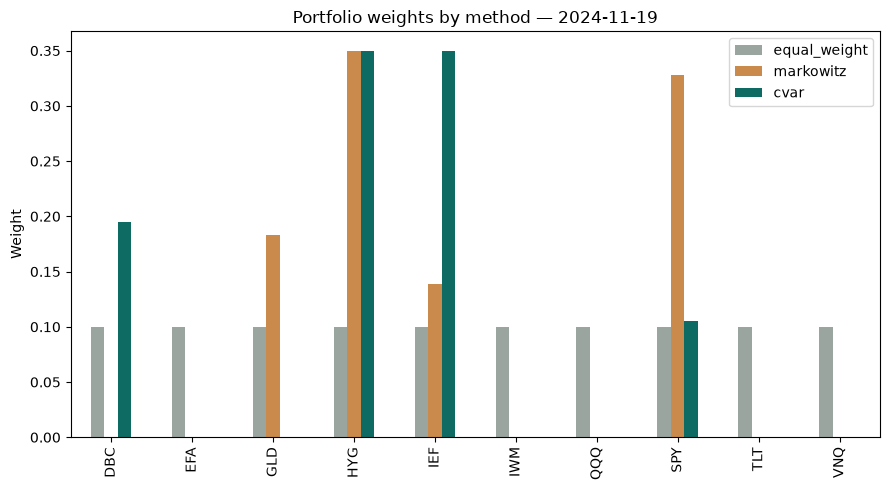

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
example_weights.plot(kind="bar", ax=ax, color=["#9aa5a0", "#c98a4b", "#0e6b64"])
ax.set_title(f"Portfolio weights by method — {example_date.date()}")
ax.set_ylabel("Weight")
plt.tight_layout()
plt.show()

## Average allocation across the whole test period

In [6]:
avg_weights = weights_df.groupby("method")[tickers].mean().round(3)
avg_weights

,DBC,EFA,GLD,HYG,IEF,IWM,QQQ,SPY,TLT,VNQ
method,,,,,,,,,,
cvar,0.125,0.005,0.055,0.350,0.350,0.000,0.003,0.028,0.084,0.000
equal_weight,0.100,0.100,0.100,0.100,0.100,0.100,0.100,0.100,0.100,0.100
markowitz,0.035,0.080,0.236,0.216,0.195,0.042,0.062,0.098,0.030,0.005


In [7]:
weights_df.to_csv(PROCESSED / "portfolio_weights.csv", index=False)
print("Saved: portfolio_weights.csv (", len(weights_df), "rows )")

Saved: portfolio_weights.csv ( 63 rows )
